In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from fsspec import filesystem 

fs = filesystem('https')

In [2]:
df = gpd.read_parquet(
    "https://github.com/oturns/example_datasets/raw/refs/heads/main/acs/ca_tracts_2021.pq", filesystem=fs
)
df = df.to_crs(32611)
df = df.replace({np.inf:np.nan})
df['pop_density'] = df.n_total_pop / df.area

la = df[df.geoid.str.startswith("06037")]
oc = df[df.geoid.str.startswith("06059")]
rside = df[df.geoid.str.startswith("06065")]

Create a san diego dataframe (`sd`) (hint: the SD county fips code is '06073')

In [3]:
sd = df[df.geoid.str.startswith("06073")]
sd

,geoid,n_mexican_pop,n_cuban_pop,n_puerto_rican_pop,n_russian_pop,n_italian_pop,n_german_pop,n_irish_pop,n_scandaniavian_pop,n_foreign_born_pop,...,p_poverty_rate_over_65,p_poverty_rate_children,p_poverty_rate_white,p_poverty_rate_black,p_poverty_rate_hispanic,p_poverty_rate_native,p_poverty_rate_asian,geometry,year,pop_density
6320,06073000100,228.0,0.0,21.0,45.0,117.0,34.0,35.0,0.0,277.0,...,0.304465,0.000000,1.082544,0.000000,1.116373,0.0,0.0,"MULTIPOLYGON (((481742.274 3623897.594, 481760...",2021,0.001926
6321,06073000201,40.0,11.0,0.0,13.0,101.0,65.0,112.0,0.0,216.0,...,2.771763,0.000000,4.677350,0.000000,0.909485,0.0,0.0,"MULTIPOLYGON (((483245.461 3624434.807, 483329...",2021,0.002674
6322,06073000202,431.0,0.0,59.0,78.0,233.0,150.0,66.0,0.0,879.0,...,0.000000,0.123305,3.699137,0.000000,1.331689,0.0,0.0,"MULTIPOLYGON (((482758.32 3623112.021, 482778....",2021,0.003154
6323,06073000301,396.0,0.0,19.0,0.0,21.0,83.0,53.0,0.0,439.0,...,0.622222,2.444444,16.311111,0.000000,4.888889,0.0,0.0,"MULTIPOLYGON (((484201.424 3623470.784, 484224...",2021,0.005604
6324,06073000302,526.0,0.0,66.0,13.0,70.0,121.0,132.0,0.0,199.0,...,1.265823,0.000000,4.887482,2.215190,3.059072,0.0,0.0,"MULTIPOLYGON (((484634.711 3622576.714, 484635...",2021,0.006126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7052,06073021900,2273.0,0.0,30.0,0.0,50.0,25.0,44.0,12.0,1004.0,...,0.272056,4.236300,11.465216,0.000000,20.093276,0.0,0.0,"MULTIPOLYGON (((487112.469 3615647.389, 487303...",2021,0.000379
7053,06073022000,2015.0,0.0,151.0,0.0,8.0,5.0,10.0,0.0,1833.0,...,2.552519,0.903546,3.930427,0.542128,4.111136,0.0,0.0,"MULTIPOLYGON (((491384.574 3616246.475, 491403...",2021,0.006172
7054,06073022101,54.0,0.0,0.0,19.0,17.0,76.0,41.0,0.0,371.0,...,0.000000,3.289474,8.245614,0.000000,0.000000,0.0,0.0,"MULTIPOLYGON (((468877.014 3667337.067, 468882...",2021,0.000182
7055,06073022102,2537.0,47.0,0.0,18.0,60.0,157.0,302.0,0.0,2234.0,...,0.860671,1.783710,3.916677,3.766995,2.981165,0.0,0.0,"MULTIPOLYGON (((471828.16 3664862.065, 471828....",2021,0.001307


## Chi Square

In [4]:
import pandas as pd
import scipy

types = ["truck", "sportscar", "hatchback", "minivan"]
draw = scipy.stats.chi2.rvs(4, 0, size=5, random_state=2)
#print(draw)

car_df = dict(zip(types, draw))
car_df = pd.Series(car_df)
car_df = car_df / car_df.sum()
car_df = car_df*400

You are a transportation planner collecting data on car accidents. After tabulating the data for one month, you count the number of fatal accidents by vehicle type, which results in data like these:

<Axes: >

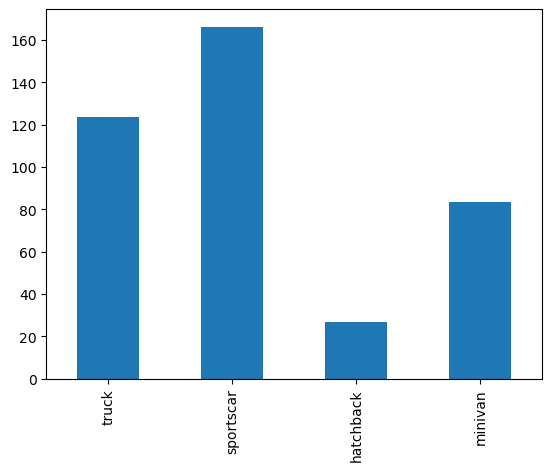

In [5]:
car_df.plot(kind='bar')

you're curious whether some vehicle types are more accident prone than others and decide to use a chi-square goodness of fit test to examine whether these vechicles get into accidents at the same rates

In words, write down the null and alternative hypotheses:

- H0: All vehicle types are equally accident prone

- HA: At least one vehicle type gets into accidents at a different rate than the others


In [6]:
from scipy.stats import chisquare

In [7]:
chisquare(car_df)

Power_divergenceResult(statistic=np.float64(105.70179446434558), pvalue=np.float64(9.229541132133133e-23))

According to conventional standards, do we reject or fail to reject the null hypothesis?

We reject the null hypothesis as the p-value is tiny.

## T-test

In [8]:
from scipy.stats import ttest_ind

We are curious whether an inland county is more "rural" than a coastal county, assuming average population density in a neighborhood is a good measure of urban/rural. Above, we calculated population density into a new variable called "pop_density". Use a two-sample t-test to compare population density in Riverside and Orange counties

In words, write down the null and alternative hypotheses:

- H0: There is no difference in population density in Riverside and Orange counties

- HA: Riverside county has a lower population density than Orange county

We start by comparing two coastal counties, Orange and San Diego

In [9]:
sd_oc = ttest_ind(sd.pop_density, oc.pop_density, equal_var=False)

In [10]:
sd_oc

TtestResult(statistic=np.float64(-2.0747571456377107), pvalue=np.float64(0.03819849690768878), df=np.float64(1347.3755942794253))

What is the p-value for the test above? Under conventional levels ($\alpha=0.05$), do we reject or accept the null hypothesis?

The p-value is small (p = 0.03819849690768878).

This means we reject the null hypothesis in this case as p < 0.05.

Now do the test for Orange and Riverside Counties using the `ttest_ind` function (assume *different* variances)

In [11]:
## your answer here
rside_oc = ttest_ind(rside.pop_density, oc.pop_density, equal_var=False)

In [12]:
rside_oc

TtestResult(statistic=np.float64(-15.594115248621948), pvalue=np.float64(1.6633232367859062e-49), df=np.float64(1058.0309282278097))

Do we accept or reject the null hypothesis?

You can never accept the null hypothesis.

We reject the null hypothesis in the case of Riverside and OC.

## ANOVA

In [13]:
from scipy.stats import f_oneway

You are interested in the labor market conditions in southern california. Specifically, you want to know if the neighborhood-level unemployment rate is the same in LA, Orange, and SD counties.

In [14]:
oc.p_unemployment_rate.mean()

np.float64(6.080652961102818)

In [15]:
sd.p_unemployment_rate.mean()

np.float64(7.485555783961273)

In [16]:
la.p_unemployment_rate.mean()

np.float64(9.574423961846268)

Write the null and alternative hypotheses that you will test

* H0: The mean unemployment rate is the same across LA, Orange, and San Diego counties
* HA: At least one county has a different mean unemployment rate than the others


use the `f_oneway` function to test this hypothesis (include `nan_policy='omit'` to make sure we ignore any NaN values)

In [17]:
# your answer here
f_oneway(oc.p_unemployment_rate, sd.p_unemployment_rate, la.p_unemployment_rate, nan_policy='omit')

F_onewayResult(statistic=np.float64(1.1357408173351302), pvalue=np.float64(0.3212927521505257))

Assuming conventional standards, do we reject or fail to reject the null hypothesis?

We fail to reject the null hypothesis.

In words, describe what the p-value represents

The p-value tells us the probability of getting our results by random chance if there was actually no real difference. A small p-value (<= 0.05) means our results are unlikely to be due to chance, so we reject the null hypothesis.